In [9]:
# Instalar Playwright y sus dependencias para Colab
!pip install playwright pytest-playwright --quiet
!playwright install chromium --with-deps --quiet

print('✅ Playwright instalado y listo.')

error: unknown option '--quiet'
✅ Playwright instalado y listo.


In [11]:
# Imports y utilidad para mostrar screenshots en el notebook
from playwright.async_api import async_playwright, Page, expect
from IPython.display import Image, display
import re

# URL de la app de práctica (TodoMVC — Playwright oficial)
TODO_URL = 'https://demo.playwright.dev/todomvc'

async def screenshot(page: Page, filename: str, title: str = ''):
    """Captura la pantalla y la muestra en el notebook."""
    path = f'/tmp/{filename}.png'
    await page.screenshot(path=path, full_page=False)
    if title:
        print(f'📸 {title}')
    display(Image(path, width=700))

print('✅ Imports listos. App objetivo:', TODO_URL)

✅ Imports listos. App objetivo: https://demo.playwright.dev/todomvc


📸 ✅ App cargada correctamente


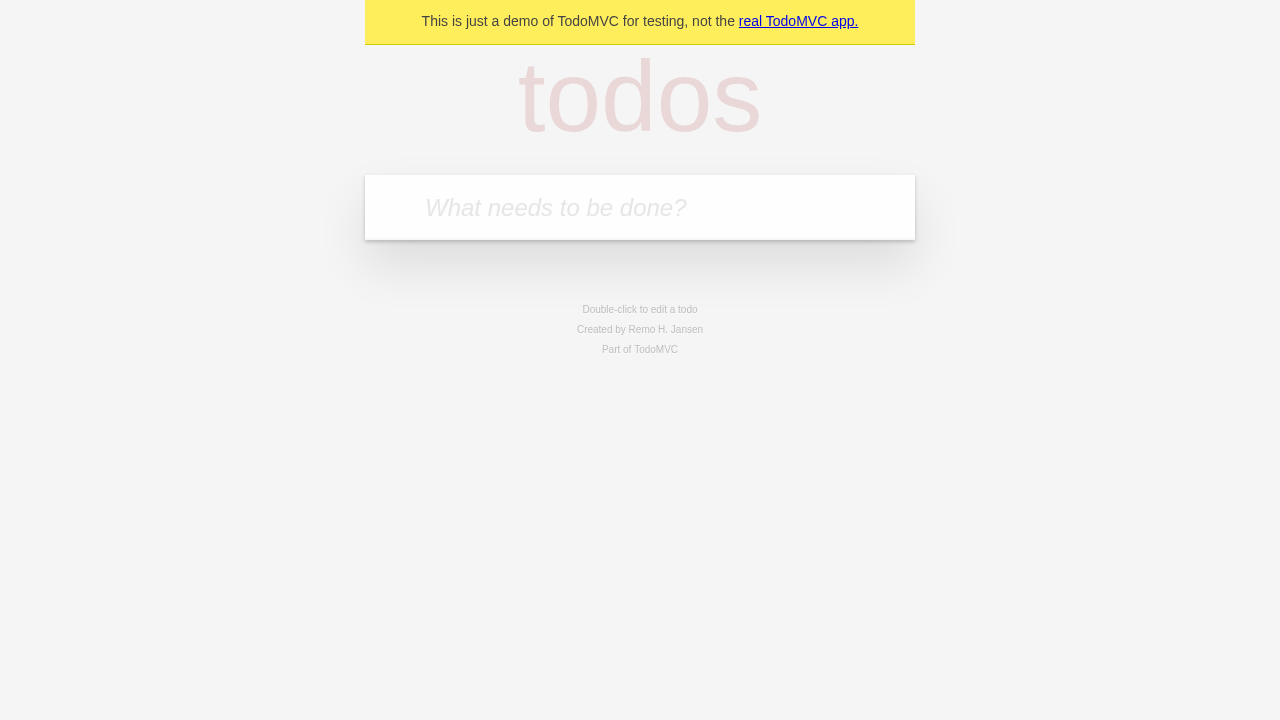

URL actual: https://demo.playwright.dev/todomvc/#/
Título:     React • TodoMVC


In [12]:
# ── Demo 1: Navegar y verificar que la app carga ─────────────

import asyncio
from playwright.async_api import async_playwright

async def run_demo1():
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=True)
        page = await browser.new_page()

        # 1. NAVEGAR
        await page.goto(TODO_URL)

        # 2. LOCALIZAR — por rol semántico (recomendado)
        titulo = page.get_by_role('heading', name='todos')
        input_nueva = page.get_by_placeholder('What needs to be done?')

        # 3. VERIFICAR con expect() — tiene auto-retry hasta 5s
        await expect(titulo).to_be_visible()
        await expect(input_nueva).to_be_visible()
        await expect(input_nueva).to_be_enabled()

        # También podemos verificar el título de la página
        await expect(page).to_have_title(re.compile('TodoMVC', re.IGNORECASE))

        await screenshot(page, 'demo1_carga', '✅ App cargada correctamente')
        print(f'URL actual: {page.url}')
        print(f'Título:     {await page.title()}')

        await browser.close()

# To run the async function in Colab
await run_demo1()

📸 ✅ 3 tareas creadas correctamente


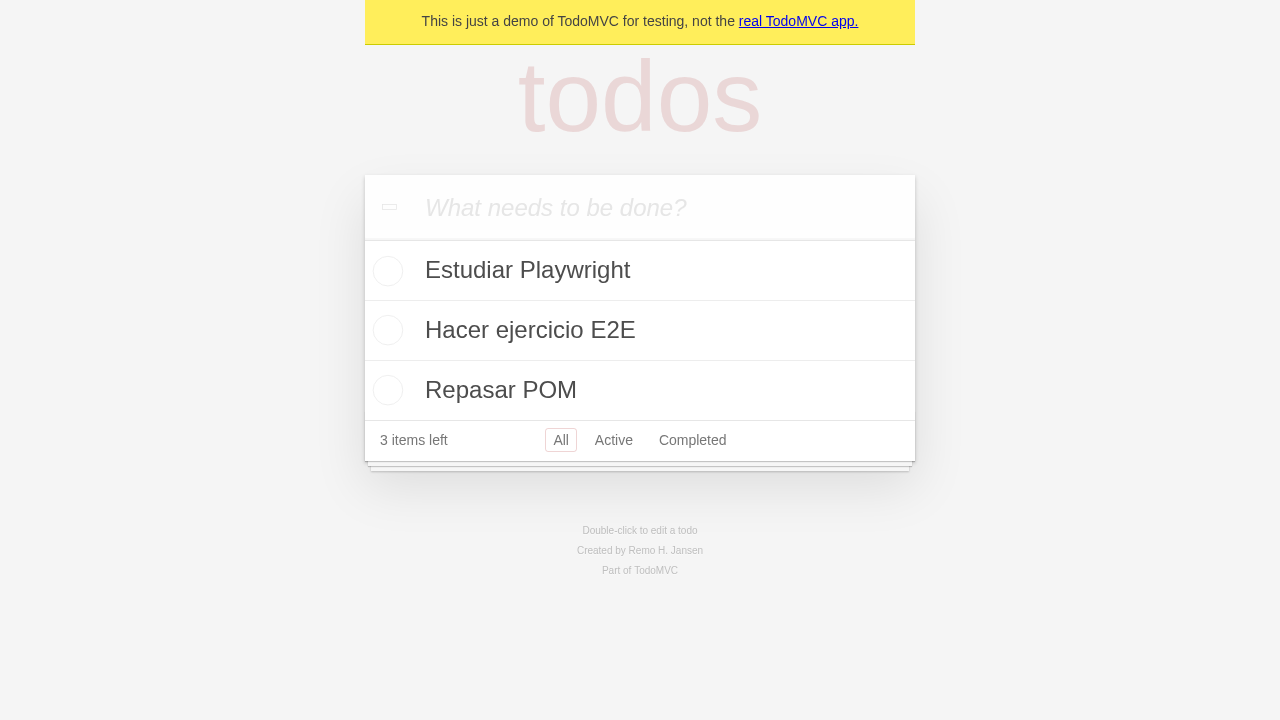

Tareas en pantalla: 3
📸 ✅ Primera tarea completada


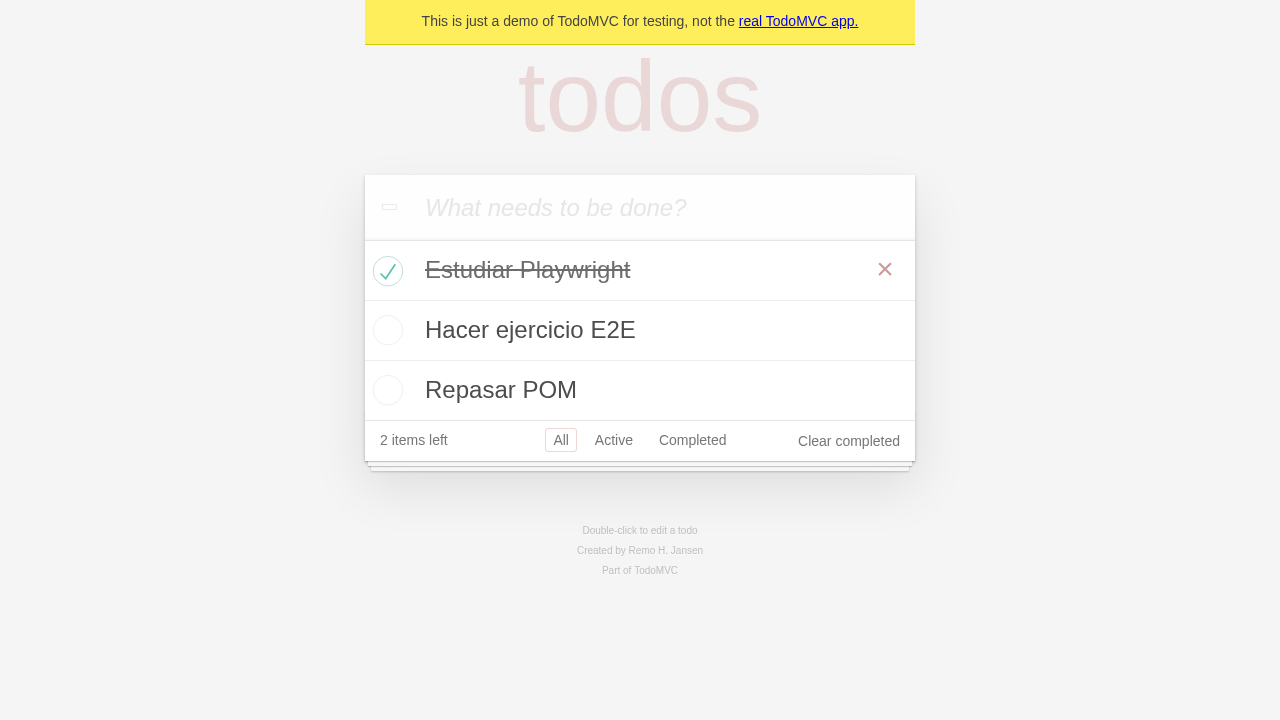

📸 ✅ Filtro "Active" — solo 2 tareas visibles


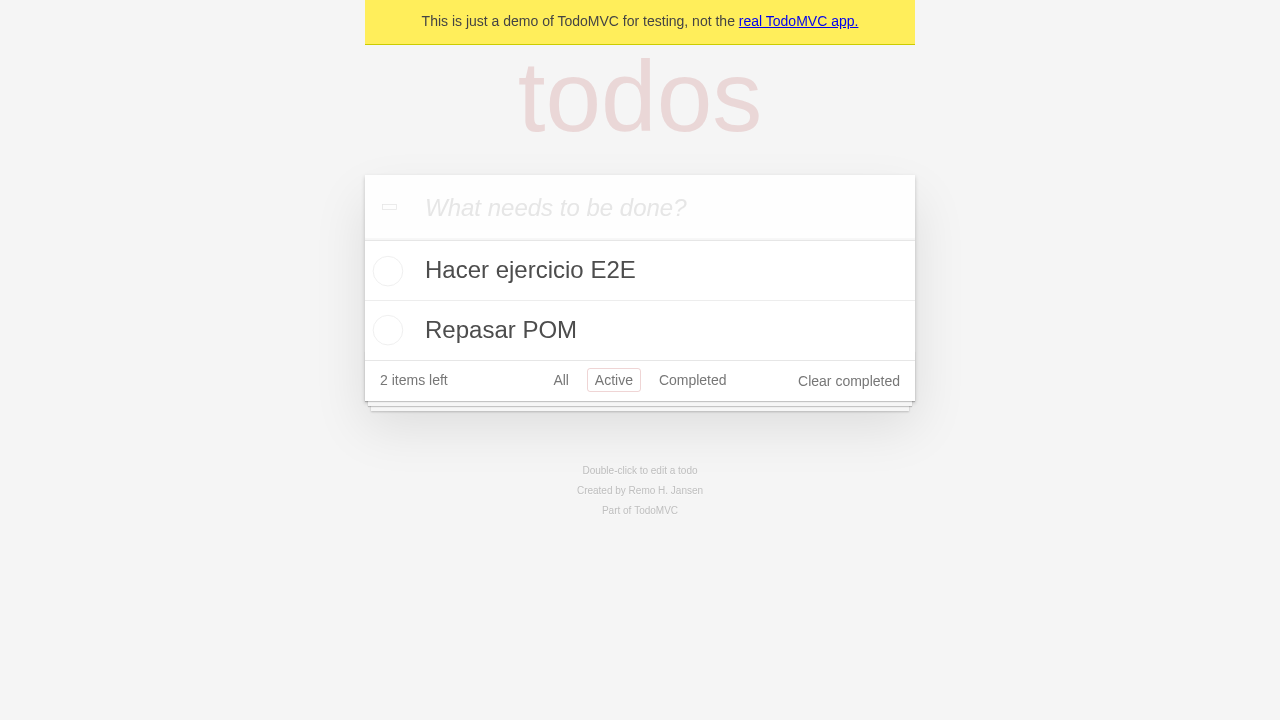


✅ Demo 2 completada — interacción verificada


In [13]:
# ── Demo 2: Crear tareas e interactuar con la UI ─────────────

import asyncio
from playwright.async_api import async_playwright, expect

async def run_demo2():
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=True)
        page = await browser.new_page()

        # Asegurar un estado limpio: limpiar localStorage y recargar la página
        await page.goto(TODO_URL)
        await page.evaluate("localStorage.clear();")
        await page.reload()

        input_nueva = page.get_by_placeholder('What needs to be done?')

        # ── CREAR 3 TAREAS ────────────────────────────────────────
        tareas = ['Estudiar Playwright', 'Hacer ejercicio E2E', 'Repasar POM']

        for tarea in tareas:
            await input_nueva.fill(tarea)        # Escribe el texto
            await input_nueva.press('Enter')     # Confirma con Enter

        # ── VERIFICAR QUE LAS 3 TAREAS EXISTEN ───────────────────
        items = page.locator('.todo-list li') # Changed to a more specific locator
        await expect(items).to_have_count(3)

        # Verificar textos específicos
        for tarea in tareas:
            await expect(page.get_by_text(tarea)).to_be_visible()

        await screenshot(page, 'demo2_tareas', '✅ 3 tareas creadas correctamente')
        print(f'Tareas en pantalla: {await items.count()}')

        # ── COMPLETAR UNA TAREA ───────────────────────────────────
        # Marca la primera tarea como completada
        primera = page.locator('.todo-list li').first # Changed to a more specific locator
        await primera.get_by_role('checkbox').check()

        # Verificar que tiene clase 'completed'
        await expect(primera).to_have_class(re.compile('completed'))

        await screenshot(page, 'demo2_completada', '✅ Primera tarea completada')

        # ── FILTRAR: solo activas ─────────────────────────────────
        await page.get_by_role('link', name='Active').click()

        # Solo deben verse las 2 tareas no completadas
        await expect(page.locator('.todo-list li')).to_have_count(2) # Changed to a more specific locator

        await screenshot(page, 'demo2_filtro', '✅ Filtro "Active" — solo 2 tareas visibles')

        await browser.close()
        print('\n✅ Demo 2 completada — interacción verificada')

await run_demo2()

In [14]:
class TodoPage:
    """
    Page Object para la app TodoMVC.
    Encapsula todos los selectores y acciones.
    Los tests nunca conocen los detalles internos de la UI.
    """

    URL = 'https://demo.playwright.dev/todomvc'

    def __init__(self, page: Page):
        self.page = page
        # ── Locators centralizados ──────────────────────────
        self.input_nueva    = page.get_by_placeholder('What needs to be done?')
        self.items          = page.locator('.todo-list li') # Cambiado a un selector más específico
        self.toggle_all     = page.get_by_label('Mark all as complete')
        self.contador       = page.locator('.todo-count strong')
        self.filtro_all     = page.get_by_role('link', name='All')
        self.filtro_active  = page.get_by_role('link', name='Active')
        self.filtro_done    = page.get_by_role('link', name='Completed')
        self.clear_done_btn = page.get_by_role('button', name='Clear completed')
        self.contador_texto = page.locator('.todo-count') # Added this locator

    async def navigate(self):
        await self.page.goto(self.URL)

    async def agregar_tarea(self, texto: str):
        """Crea una nueva tarea con el texto dado."""
        await self.input_nueva.fill(texto)
        await self.input_nueva.press('Enter')

    async def agregar_tareas(self, textos: list):
        """Crea múltiples tareas de una vez."""
        for texto in textos:
            await self.agregar_tarea(texto)

    async def completar_tarea(self, texto: str):
        """Marca como completada la tarea con el texto dado."""
        item = self.items.filter(has_text=texto)
        await item.get_by_role('checkbox').check()

    async def eliminar_tarea(self, texto: str):
        """Elimina la tarea con el texto dado (hover + clic en X)."""
        item = self.items.filter(has_text=texto)
        await item.hover()
        await item.get_by_role('button', name='Delete').click()

    async def get_conteo_pendientes(self) -> int:
        """Retorna el número de tareas pendientes según el contador."""
        return int(await self.contador.inner_text())

    async def get_conteo_items(self) -> int:
        """Retorna el número de items visibles en la lista."""
        return await self.items.count()

    async def filtrar_activas(self):
        await self.filtro_active.click()

    async def filtrar_completadas(self):
        await self.filtro_done.click()

    async def filtrar_todas(self):
        await self.filtro_all.click()

    async def limpiar_completadas(self):
        await self.clear_done_btn.click()


print('✅ Clase TodoPage definida.')
print('   Los tests ahora llaman métodos como:')
print('   todo.agregar_tarea("Estudiar")  — sin conocer los selectores internos')

✅ Clase TodoPage definida.
   Los tests ahora llaman métodos como:
   todo.agregar_tarea("Estudiar")  — sin conocer los selectores internos


📸 App vacía al inicio


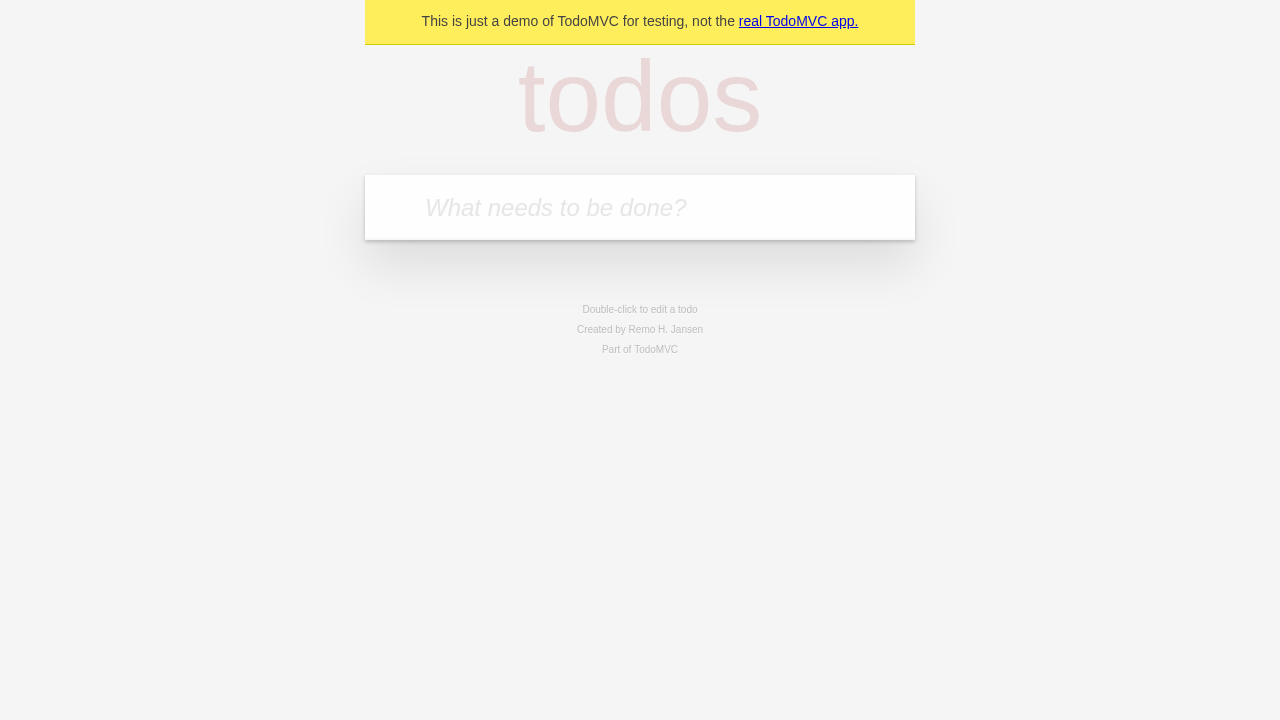

📸 4 tareas creadas


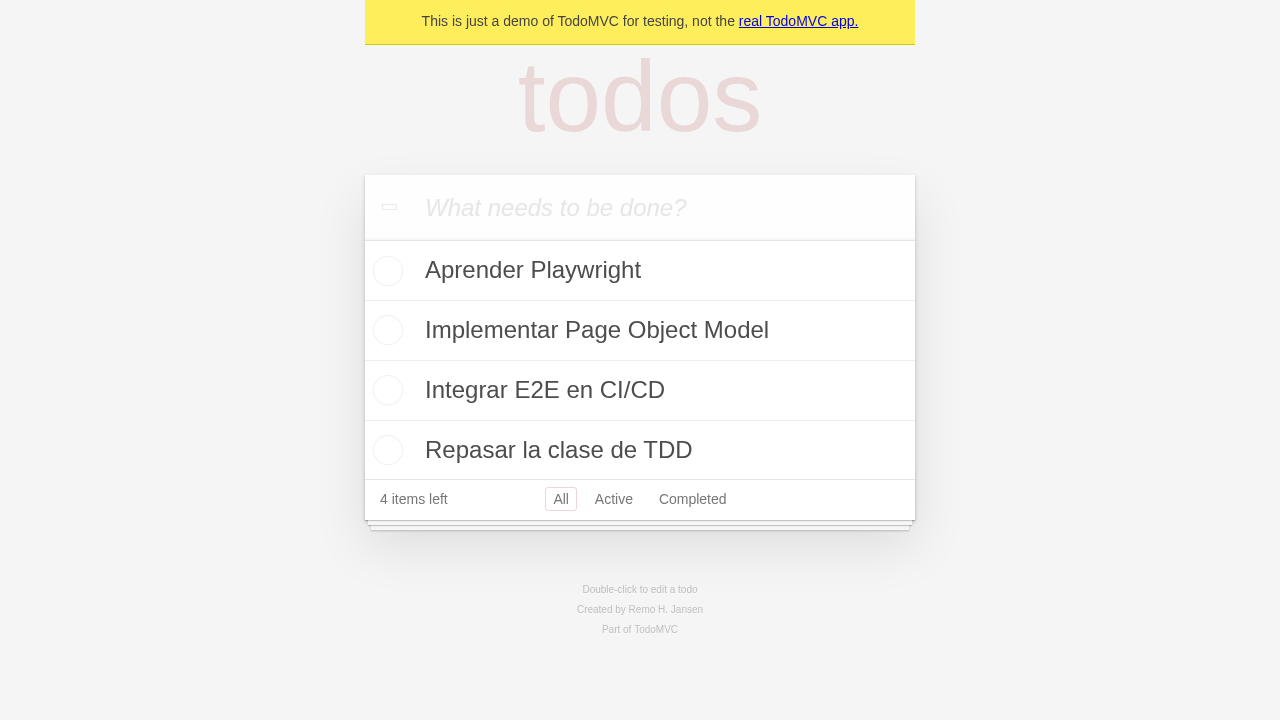

Pendientes: 4
📸 2 tareas completadas


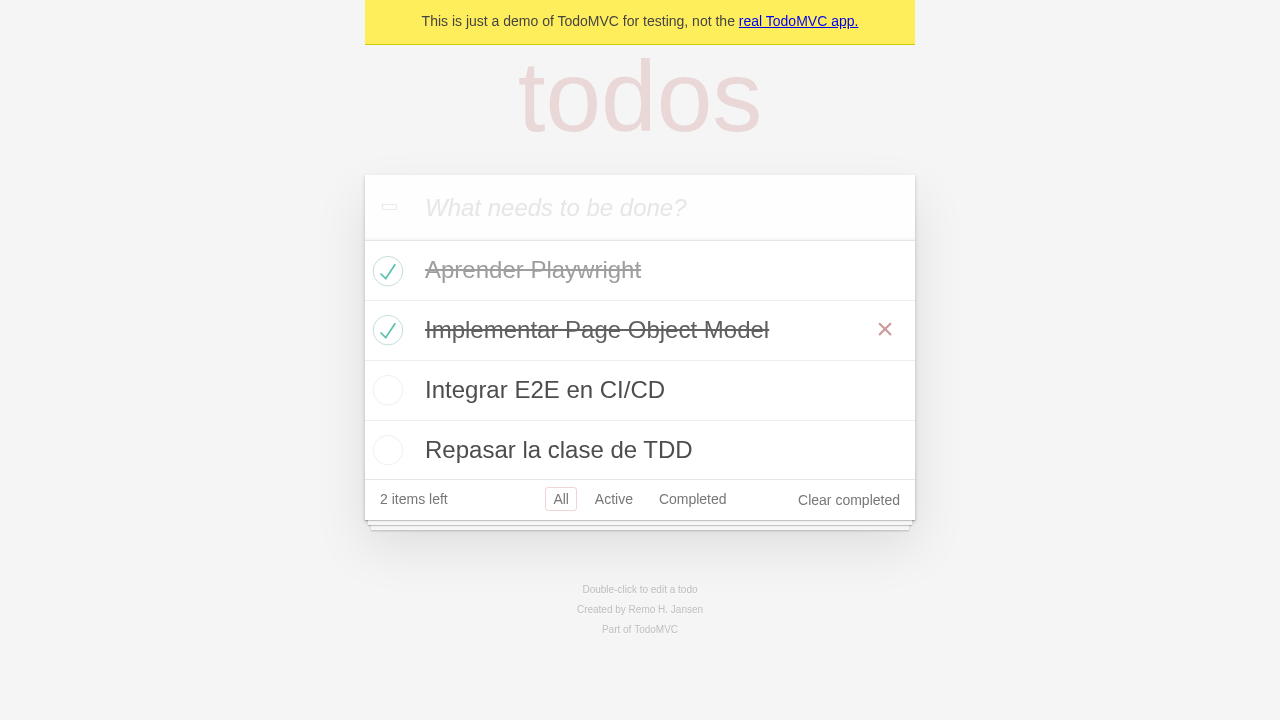

Pendientes después de completar 2: 2
📸 Filtro: solo activas (2)


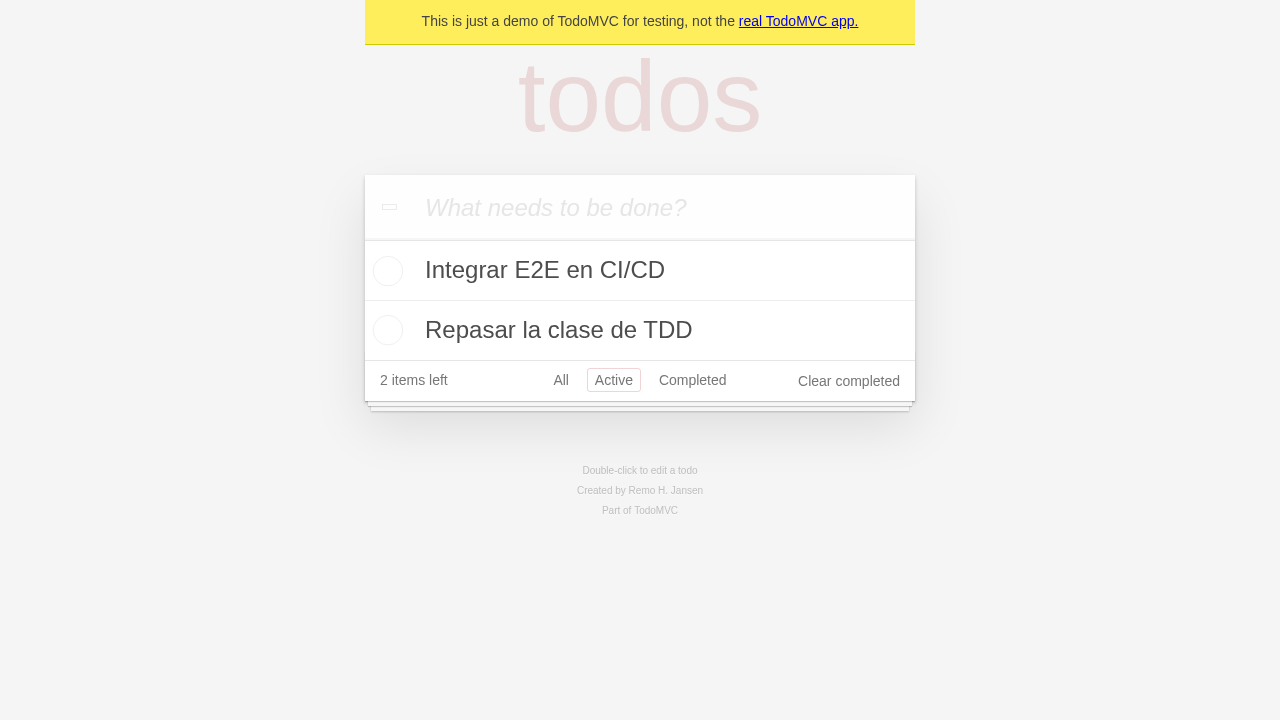

📸 Filtro: solo completadas (2)


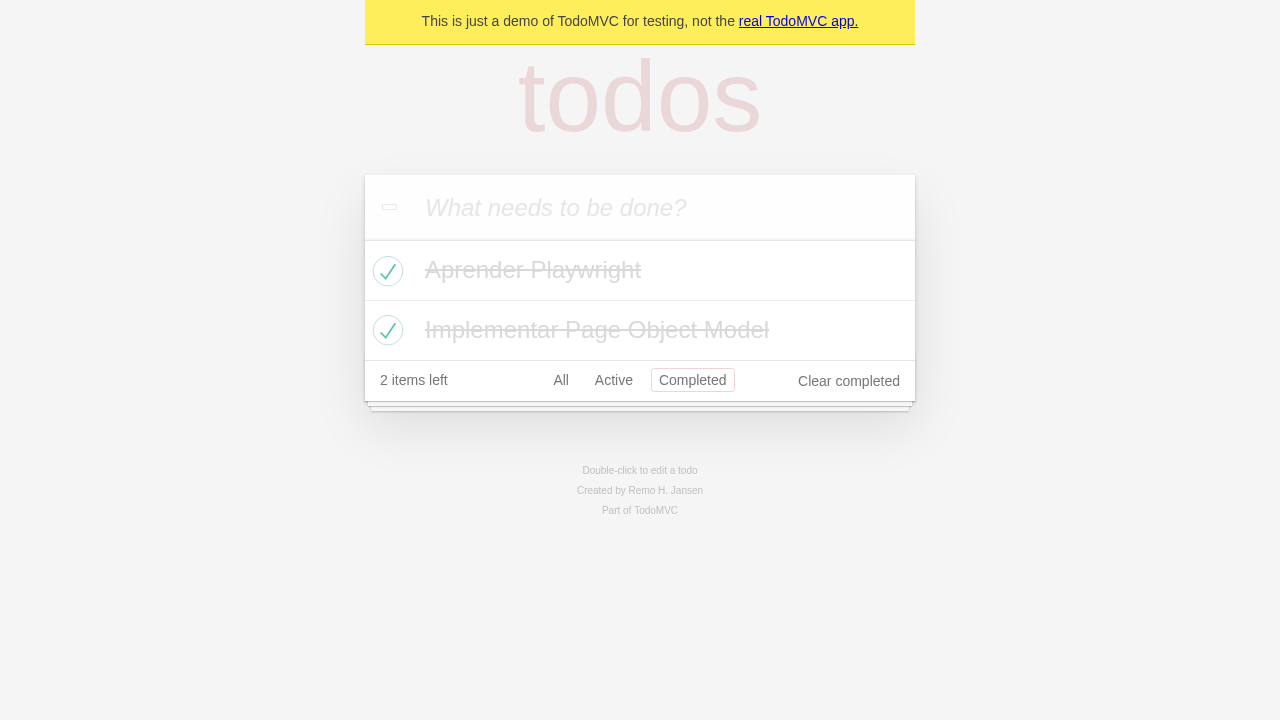

📸 Completadas eliminadas — quedan 2


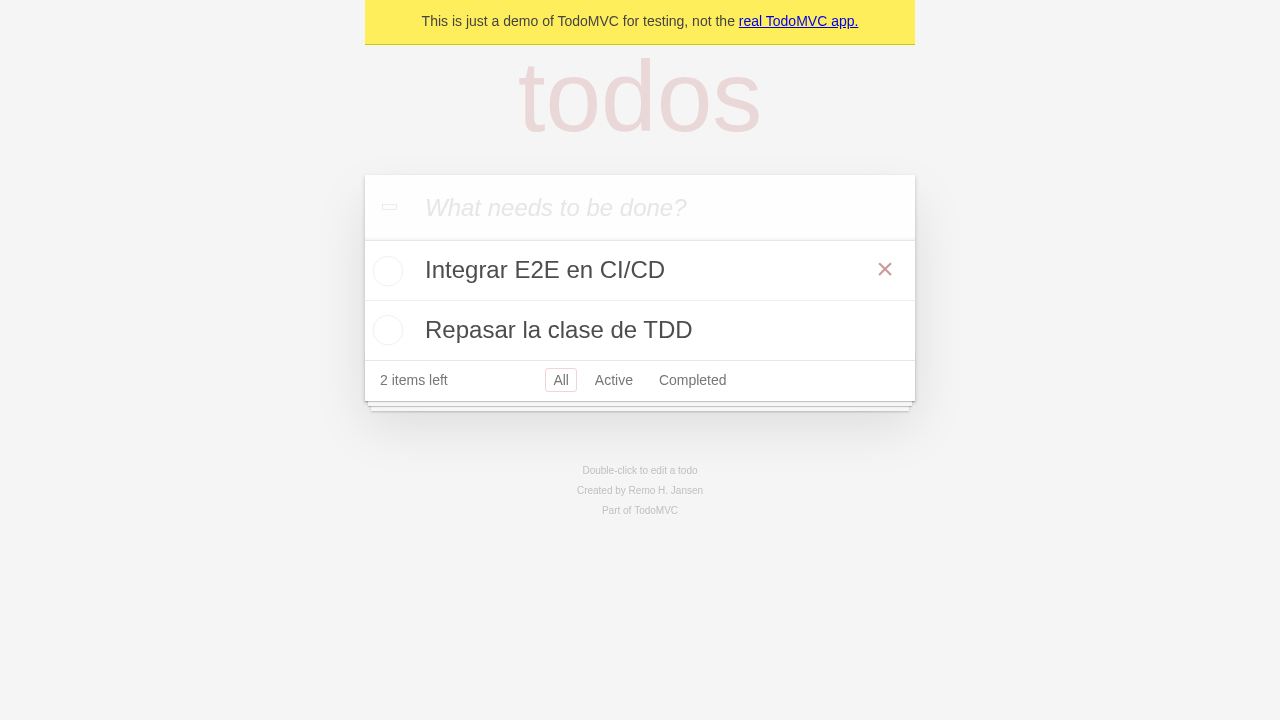

Items después de limpiar: 2

✅ Flujo completo con POM — todos los assertions pasaron


In [15]:
# ── Demo 3: Flujo completo usando el POM ─────────────────────
# Observa cómo el test es legible y no contiene selectores

import asyncio
from playwright.async_api import async_playwright, expect

async def run_demo3():
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=True)
        page = await browser.new_page()
        todo = TodoPage(page)

        # Asegurar un estado limpio para esta demo
        await page.goto(TODO_URL) # Necesario para que localStorage.clear() funcione en la página correcta
        await page.evaluate("localStorage.clear();")
        await page.reload()

        # ── ARRANQUE ──────────────────────────────────────────────
        await todo.navigate()
        await screenshot(page, 'pom_inicio', 'App vacía al inicio')

        # ── CREAR TAREAS ──────────────────────────────────────────
        await todo.agregar_tareas([
            'Aprender Playwright',
            'Implementar Page Object Model',
            'Integrar E2E en CI/CD',
            'Repasar la clase de TDD',
        ])

        await expect(todo.items).to_have_count(4)
        await expect(todo.contador_texto).to_have_text('4 items left') # Usar el nuevo locator
        await screenshot(page, 'pom_4tareas', '4 tareas creadas')
        print(f'Pendientes: {await todo.get_conteo_pendientes()}')

        # ── COMPLETAR ALGUNAS ─────────────────────────────────────
        await todo.completar_tarea('Aprender Playwright')
        await todo.completar_tarea('Implementar Page Object Model')

        await expect(todo.contador_texto).to_have_text('2 items left') # Usar el nuevo locator
        await screenshot(page, 'pom_completadas', '2 tareas completadas')
        print(f'Pendientes después de completar 2: {await todo.get_conteo_pendientes()}')

        # ── FILTROS ───────────────────────────────────────────────
        await todo.filtrar_activas()
        await expect(todo.items).to_have_count(2)
        await screenshot(page, 'pom_activas', 'Filtro: solo activas (2)')

        await todo.filtrar_completadas()
        await expect(todo.items).to_have_count(2)
        await screenshot(page, 'pom_completadas_filtro', 'Filtro: solo completadas (2)')

        # ── LIMPIAR COMPLETADAS ───────────────────────────────────
        await todo.limpiar_completadas()
        await todo.filtrar_todas()
        await expect(todo.items).to_have_count(2)
        await screenshot(page, 'pom_limpio', 'Completadas eliminadas — quedan 2')
        print(f'Items después de limpiar: {await todo.get_conteo_items()}')

        await browser.close()
        print('\n✅ Flujo completo con POM — todos los assertions pasaron')

await run_demo3()

In [25]:
import asyncio
from playwright.async_api import async_playwright, Page, expect

# URL correcta
TODO_URL = "https://demo.playwright.dev/todomvc"

# ════════════════════════════════════════════════════════════
# 🧱 Page Object Model
# ════════════════════════════════════════════════════════════

class TodoPage:
    def __init__(self, page: Page):
        self.page = page
        self.input = page.get_by_placeholder("What needs to be done?")
        self.items = page.locator(".todo-list li")
        self.contador = page.locator(".todo-count")

    async def navigate(self):
        await self.page.goto(TODO_URL)

    async def agregar_tarea(self, texto):
        await self.input.fill(texto)
        await self.page.keyboard.press("Enter")

    async def agregar_tareas(self, lista):
        for tarea in lista:
            await self.agregar_tarea(tarea)

    # 🔥 FIX IMPORTANTE AQUÍ
    async def completar_tarea(self, texto):
        item = self.page.locator(".todo-list li", has_text=texto)
        checkbox = item.locator("input.toggle")
        await checkbox.check()

    async def filtrar_activas(self):
        await self.page.locator('a[href="#/active"]').click()

    async def filtrar_completadas(self):
        await self.page.locator('a[href="#/completed"]').click()

    async def filtrar_todas(self):
        await self.page.locator('a[href="#/"]').click() # Corrected href from #/c to #/

    async def limpiar_completadas(self):
        await self.page.get_by_text("Clear completed").click()


# ════════════════════════════════════════════════════════════
# 🧪 TESTS
# ════════════════════════════════════════════════════════════

async def test_app_inicia_vacia(page: Page):
    todo = TodoPage(page)
    await todo.navigate()

    await expect(todo.items).to_have_count(0)


async def test_crear_tarea_aparece_en_lista(page: Page):
    todo = TodoPage(page)
    await todo.navigate()

    await todo.agregar_tarea('Estudiar Playwright')

    await expect(todo.items).to_have_count(1)
    await expect(todo.items).to_contain_text(['Estudiar Playwright'])


async def test_completar_tarea_reduce_contador(page: Page):
    todo = TodoPage(page)
    await todo.navigate()

    await todo.agregar_tareas(['Tarea A', 'Tarea B', 'Tarea C'])
    await todo.completar_tarea('Tarea A')

    await expect(todo.contador).to_have_text('2 items left')


async def test_filtro_active_oculta_completadas(page: Page):
    todo = TodoPage(page)
    await todo.navigate()

    await todo.agregar_tareas(['Primera', 'Segunda', 'Tercera'])
    await todo.completar_tarea('Primera')

    await todo.filtrar_activas()

    await expect(todo.items).to_have_count(2)
    await expect(todo.items).not_to_contain_text(['Primera'])


async def test_filtro_completadas_muestra_solo_completadas(page: Page):
    todo = TodoPage(page)
    await todo.navigate()

    await todo.agregar_tareas(['Activa 1', 'Completada 1', 'Activa 2', 'Completada 2'])
    await todo.completar_tarea('Completada 1')
    await todo.completar_tarea('Completada 2')

    await todo.filtrar_completadas()

    await expect(todo.items).to_have_count(2)
    await expect(todo.items).to_contain_text(['Completada 1', 'Completada 2'])


async def test_limpiar_completadas_las_elimina(page: Page):
    todo = TodoPage(page)
    await todo.navigate()

    await todo.agregar_tareas(['Keep me', 'Delete me 1', 'Delete me 2'])
    await todo.completar_tarea('Delete me 1')
    await todo.completar_tarea('Delete me 2')

    await todo.limpiar_completadas()
    await todo.filtrar_todas()

    await expect(todo.items).to_have_count(1)
    await expect(todo.items).to_contain_text(['Keep me'])


# ════════════════════════════════════════════════════════════
# ▶ RUNNER
# ════════════════════════════════════════════════════════════

todos_los_tests = [
    test_app_inicia_vacia,
    test_crear_tarea_aparece_en_lista,
    test_completar_tarea_reduce_contador,
    test_filtro_active_oculta_completadas,
    test_filtro_completadas_muestra_solo_completadas,
    test_limpiar_completadas_las_elimina,
]


async def run_all_tests():
    resultados = []

    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=True)

        for fn in todos_los_tests:
            page = await browser.new_page()
            nombre = fn.__name__

            try:
                # limpiar estado antes de cada test
                await page.goto(TODO_URL)
                await page.evaluate("localStorage.clear();")
                await page.reload()

                await fn(page)

                resultados.append((nombre, '✅ PASS', None))

            except Exception as e:
                resultados.append((nombre, '❌ FAIL', str(e)[:120]))

            finally:
                await page.close()

        await browser.close()

    # reporte
    print('\n' + '='*60)
    print('  RESULTADOS DE LOS TESTS')
    print('='*60)

    passed = sum(1 for _, s, _ in resultados if 'PASS' in s)

    for nombre, status, error in resultados:
        print(f'  {status}  {nombre}')
        if error:
            print(f'         └─ {error}')

    print('='*60)
    print(f'  {passed}/{len(resultados)} tests pasaron')
    print('='*60)

    if passed == len(resultados):
        print('\n🔥 ¡Todos los tests pasan!')
    else:
        print(f'\n⚠️ {len(resultados)-passed} test(s) fallaron')


# ejecutar
await run_all_tests()


  RESULTADOS DE LOS TESTS
  ✅ PASS  test_app_inicia_vacia
  ✅ PASS  test_crear_tarea_aparece_en_lista
  ✅ PASS  test_completar_tarea_reduce_contador
  ✅ PASS  test_filtro_active_oculta_completadas
  ✅ PASS  test_filtro_completadas_muestra_solo_completadas
  ✅ PASS  test_limpiar_completadas_las_elimina
  6/6 tests pasaron

🔥 ¡Todos los tests pasan!
